# EDA — Customer Support Tickets (split de treino)

Exploração mais profunda do dataset (Kaggle: *Customer Support Ticket Dataset*), como preparação para o projeto real de suporte ao cliente.

⚠️ **Este notebook lê `data/processed/train.csv`** (gerado por `customer_support_analytics/dataset.py`), não o CSV bruto. É intencional: explorar só o split de treino evita espiar val/teste antes de qualquer decisão de modelagem. Rode `make data` antes, se `data/processed/` ainda não existir. A checagem mínima sobre o dataset bruto que definiu os parâmetros desse split está em `1.0-cb-eda-raw-pre-split.ipynb`.

**Objetivo:** entender estrutura, qualidade e distribuições dos dados antes de definir o problema de modelagem (ex.: previsão de prioridade, tempo de resolução, satisfação do cliente).

**Índice**
1. Carregamento dos dados
2. Visão geral: tipos e estrutura
3. Valores ausentes
4. Distribuição de status e variáveis categóricas
5. Produtos mais frequentes
6. Perfil demográfico: idade
7. Tamanho do texto da descrição do ticket
8. Volume de tickets por data de compra
9. Satisfação do cliente (tickets fechados)
10. Nota sobre os campos de tempo (1ª resposta / resolução)
11. Resumo dos principais achados
12. Próximos passos


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from customer_support_analytics.config import PROCESSED_DATA_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})


2026-08-21 09:30:48.577 | INFO     | customer_support_analytics.config:<module>:11 - PROJ_ROOT path is: C:\Users\Micro\Documents\GitHub\estudo_customer_support


## 1. Carregamento dos dados


In [ ]:
df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
print(f"shape: {df.shape}")
df.head()


shape: (5920, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
1,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
2,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
3,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
4,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


## 2. Visão geral: tipos e estrutura

Este é o split de **treino** (~70% dos tickets, agrupado por cliente e estratificado por `Ticket Priority` — ver `1.0-cb-eda-raw-pre-split.ipynb`). `Ticket ID` é único dentro do split (sem duplicados). Colunas de data/hora vêm como `str` e serão convertidas quando necessário.


In [ ]:
df.info()
print("\nTicket ID duplicado:", df["Ticket ID"].duplicated().sum())
print("E-mails únicos:", df["Customer Email"].nunique(), "de", len(df), "linhas (alguns clientes abriram mais de 1 ticket)")


<class 'pandas.DataFrame'>
RangeIndex: 5920 entries, 0 to 5919
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     5920 non-null   int64  
 1   Customer Name                 5920 non-null   str    
 2   Customer Email                5920 non-null   str    
 3   Customer Age                  5920 non-null   int64  
 4   Customer Gender               5920 non-null   str    
 5   Product Purchased             5920 non-null   str    
 6   Date of Purchase              5920 non-null   str    
 7   Ticket Type                   5920 non-null   str    
 8   Ticket Subject                5920 non-null   str    
 9   Ticket Description            5920 non-null   str    
 10  Ticket Status                 5920 non-null   str    
 11  Resolution                    1917 non-null   str    
 12  Ticket Priority               5920 non-null   str    
 13  Ticket Channel

## 3. Valores ausentes

Quatro colunas têm valores ausentes: `Resolution`, `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating`.


In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"ausentes": missing, "pct": missing_pct})


,ausentes,pct
Resolution,4003,67.6
Time to Resolution,4003,67.6
Customer Satisfaction Rating,4003,67.6
First Response Time,1984,33.5


In [ ]:
status_counts = df["Ticket Status"].value_counts()
alignment = pd.DataFrame({
    "tickets": status_counts,
    "tem 1ª resposta": df.groupby("Ticket Status")["First Response Time"].apply(lambda s: s.notna().sum()),
    "tem resolução": df.groupby("Ticket Status")["Resolution"].apply(lambda s: s.notna().sum()),
    "tem avaliação": df.groupby("Ticket Status")["Customer Satisfaction Rating"].apply(lambda s: s.notna().sum()),
})
alignment


,tickets,tem 1ª resposta,tem resolução,tem avaliação
Ticket Status,,,,
Closed,1917,1917,1917,1917
Open,1984,0,0,0
Pending Customer Response,2019,2019,0,0


**Achado principal:** os valores ausentes não são aleatórios — são 100% estruturais, ligados ao estágio do ciclo de vida do ticket (mesmo padrão observado no dataset completo, antes do split):

- **Open**: ainda não recebeu 1ª resposta → explica os nulos em `First Response Time`.
- **Open + Pending Customer Response**: ainda não fechados → sem `Resolution`, `Time to Resolution` nem `Customer Satisfaction Rating`.
- **Closed**: 100% preenchido nas 4 colunas.

Ou seja, não é um problema de qualidade a ser imputado — é a **semântica do ciclo de vida do ticket**. Qualquer feature construída sobre `Resolution`/`Time to Resolution`/`Customer Satisfaction Rating` só existe para tickets fechados.


## 4. Distribuição de status e variáveis categóricas

Cada gráfico abaixo descreve uma única variável (uma série), por isso usamos um único tom (azul) em vez da paleta categórica completa — a identidade de cada categoria já está no rótulo do eixo.


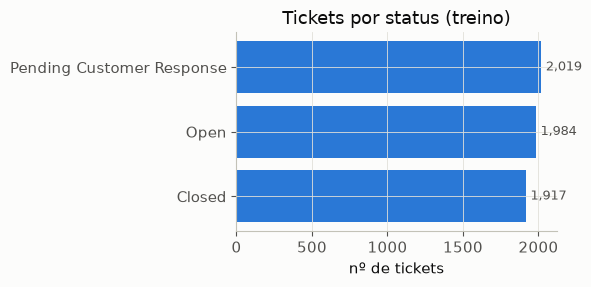

In [ ]:
BLUE = CATEGORICAL_PALETTE[0]

fig, ax = plt.subplots(figsize=(6, 3))
order = df["Ticket Status"].value_counts()
ax.barh(order.index[::-1], order.values[::-1], color=BLUE)
ax.set_title("Tickets por status (treino)")
ax.set_xlabel("nº de tickets")
for i, v in enumerate(order.values[::-1]):
    ax.text(v + 30, i, f"{v:,}", va="center", color="#52514e", fontsize=9)
plt.tight_layout()
plt.show()


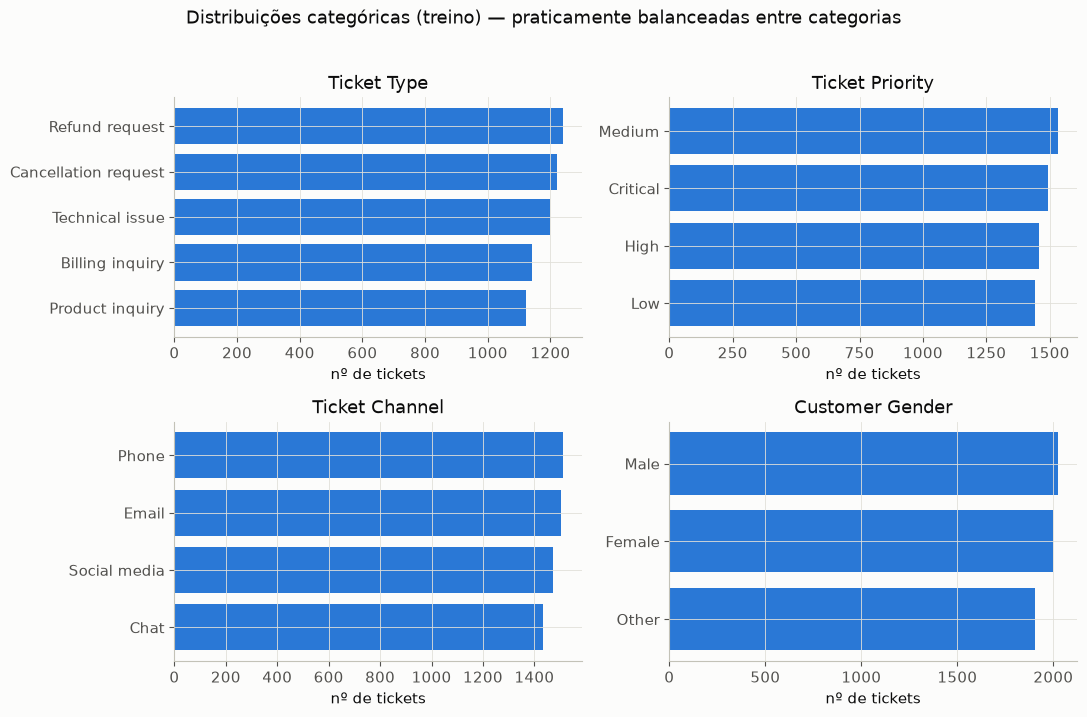

In [ ]:
cols = ["Ticket Type", "Ticket Priority", "Ticket Channel", "Customer Gender"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(cols, axes.flat):
    counts = df[col].value_counts().sort_values()
    ax.barh(counts.index, counts.values, color=BLUE)
    ax.set_title(col)
    ax.set_xlabel("nº de tickets")
fig.suptitle("Distribuições categóricas (treino) — praticamente balanceadas entre categorias", y=1.02)
plt.tight_layout()
plt.show()


## 5. Produtos mais frequentes

Top 15 produtos de `Product Purchased` abaixo — sem produto dominante isolado.


nº de produtos distintos: 42


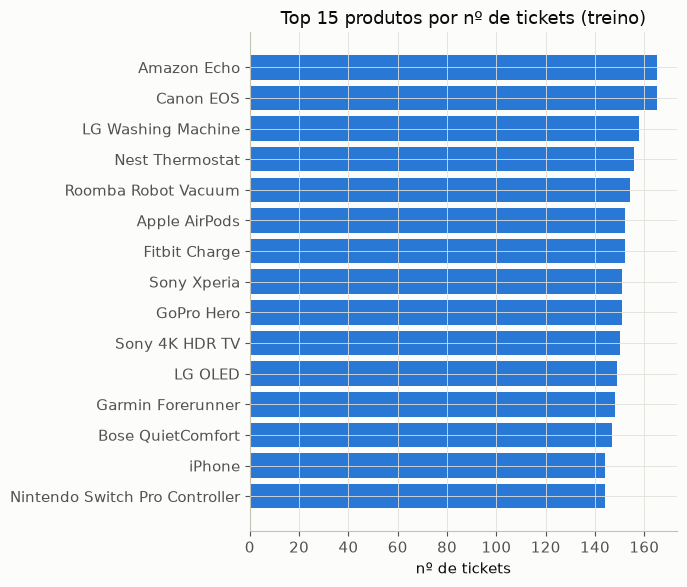

In [ ]:
print("nº de produtos distintos:", df["Product Purchased"].nunique())

top15 = df["Product Purchased"].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15.index, top15.values, color=BLUE)
ax.set_title("Top 15 produtos por nº de tickets (treino)")
ax.set_xlabel("nº de tickets")
plt.tight_layout()
plt.show()


## 6. Perfil demográfico: idade


count    5920.000000
mean       43.895777
std        15.207628
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


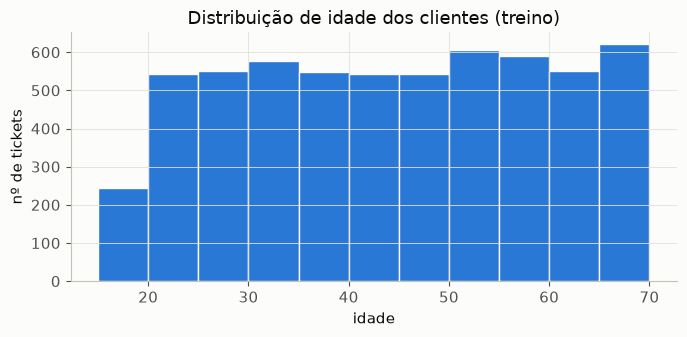

In [ ]:
print(df["Customer Age"].describe())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(df["Customer Age"], bins=range(15, 75, 5), color=BLUE, edgecolor="#fcfcfb")
ax.set_title("Distribuição de idade dos clientes (treino)")
ax.set_xlabel("idade")
ax.set_ylabel("nº de tickets")
plt.tight_layout()
plt.show()


## 7. Tamanho do texto da descrição do ticket

Relevante para decisões futuras de NLP (ex.: truncamento/tokenização) sobre `Ticket Description`.


count    5920.000000
mean      289.726520
std        43.757781
min       151.000000
25%       272.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: Ticket Description, dtype: float64


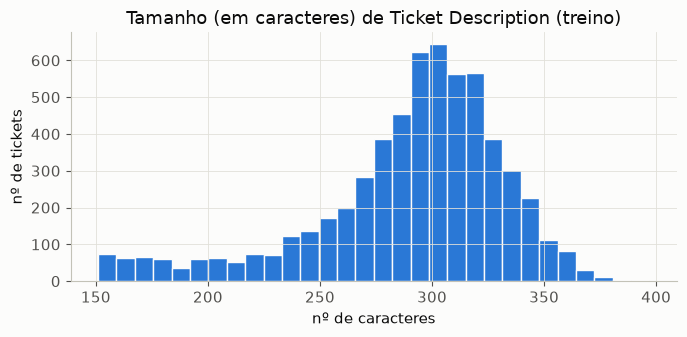

In [ ]:
desc_len = df["Ticket Description"].str.len()
print(desc_len.describe())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(desc_len, bins=30, color=BLUE, edgecolor="#fcfcfb")
ax.set_title("Tamanho (em caracteres) de Ticket Description (treino)")
ax.set_xlabel("nº de caracteres")
ax.set_ylabel("nº de tickets")
plt.tight_layout()
plt.show()


## 8. Volume de tickets por data de compra

⚠️ `Date of Purchase` é a data de **compra do produto**, não a data de **abertura do ticket** — o dataset não tem uma coluna de data de abertura. O gráfico abaixo mostra sazonalidade de compras, não volume de atendimento.


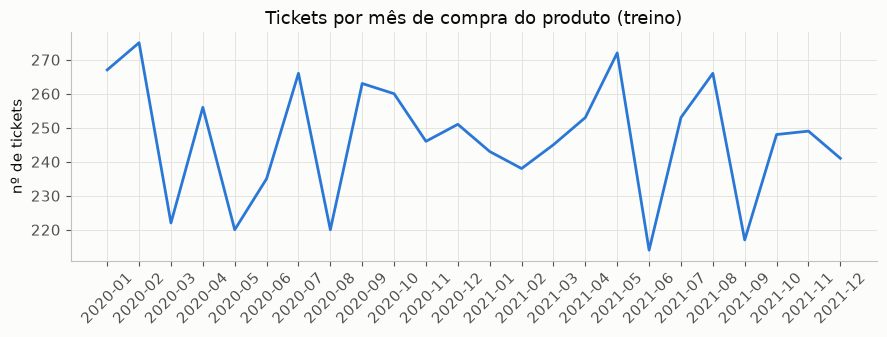

In [ ]:
purchase_date = pd.to_datetime(df["Date of Purchase"])
monthly = purchase_date.dt.to_period("M").value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(monthly.index.astype(str), monthly.values, color=BLUE, linewidth=2)
ax.set_title("Tickets por mês de compra do produto (treino)")
ax.set_ylabel("nº de tickets")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 9. Satisfação do cliente (apenas tickets fechados)

`Customer Satisfaction Rating` só existe para tickets `Closed` (seção 3).


count    1917.000000
mean        3.004173
std         1.405322
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


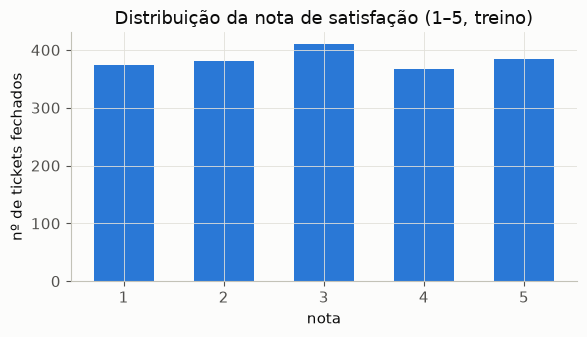

In [ ]:
closed = df[df["Ticket Status"] == "Closed"]
print(closed["Customer Satisfaction Rating"].describe())

fig, ax = plt.subplots(figsize=(6, 3.5))
rating_counts = closed["Customer Satisfaction Rating"].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, color=BLUE, width=0.6)
ax.set_title("Distribuição da nota de satisfação (1–5, treino)")
ax.set_xlabel("nota")
ax.set_ylabel("nº de tickets fechados")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()


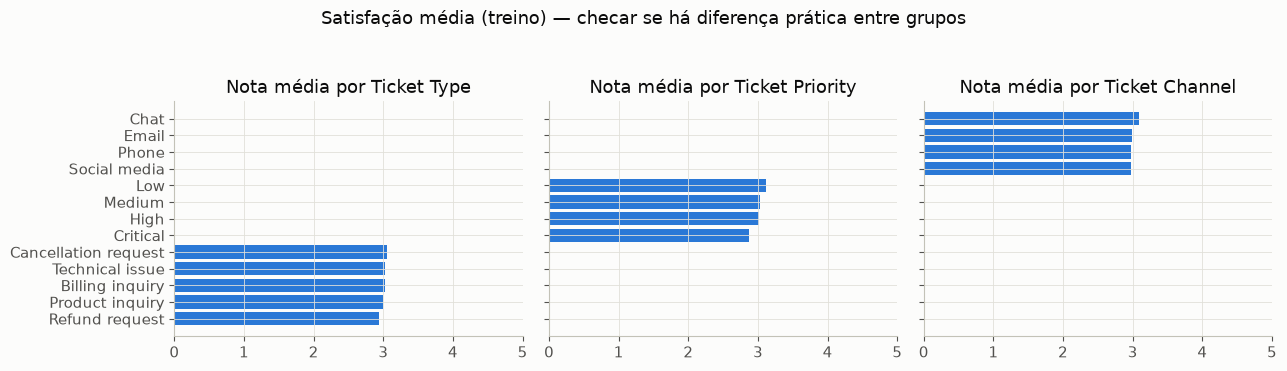

In [ ]:
group_cols = ["Ticket Type", "Ticket Priority", "Ticket Channel"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for col, ax in zip(group_cols, axes):
    mean_rating = closed.groupby(col)["Customer Satisfaction Rating"].mean().sort_values()
    ax.barh(mean_rating.index, mean_rating.values, color=BLUE)
    ax.set_title(f"Nota média por {col}")
    ax.set_xlim(0, 5)
fig.suptitle("Satisfação média (treino) — checar se há diferença prática entre grupos", y=1.05)
plt.tight_layout()
plt.show()


## 10. Nota sobre os campos de tempo (1ª resposta / resolução)

⚠️ **Alerta de qualidade de dados.** Antes de usar `First Response Time` e `Time to Resolution` para métricas de SLA, é preciso verificar se eles são confiáveis.


In [ ]:
frt = pd.to_datetime(df["First Response Time"])
ttr = pd.to_datetime(df["Time to Resolution"])

print("Datas únicas em First Response Time:", sorted(frt.dt.date.dropna().unique()))
print("Datas únicas em Time to Resolution:", sorted(ttr.dt.date.dropna().unique()))

diff_hours = (ttr - frt).dropna().dt.total_seconds() / 3600
print(f"\nResolução − 1ª resposta (horas): min={diff_hours.min():.1f}, média={diff_hours.mean():.1f}, max={diff_hours.max():.1f}")
print(f"% de casos com resolução ANTES da 1ª resposta: {(diff_hours < 0).mean():.1%}")


Datas únicas em First Response Time: [datetime.date(2023, 5, 31), datetime.date(2023, 6, 1), datetime.date(2023, 6, 2)]
Datas únicas em Time to Resolution: [datetime.date(2023, 5, 31), datetime.date(2023, 6, 1), datetime.date(2023, 6, 2)]

Resolução − 1ª resposta (horas): min=-22.9, média=-0.1, max=23.5
% de casos com resolução ANTES da 1ª resposta: 49.9%


**Interpretação:** os timestamps caem em uma janela muito estreita de dias, sem relação com a data de compra nem com o status do ticket, e uma fração expressiva dos casos tem a resolução ocorrendo *antes* da 1ª resposta — o que é logicamente impossível em um processo real de atendimento.

Isso é consistente com o padrão conhecido deste dataset público (Kaggle): esses dois campos parecem ter sido gerados de forma aleatória/sintética, não são timestamps reais de atendimento. **Recomendação:** não usar `First Response Time` e `Time to Resolution` (nem a duração entre eles) como features de SLA/tempo de resposta sem antes confirmar a origem/geração desses dados com quem forneceu o dataset real do projeto.


## 11. Resumo dos principais achados

- **Ciclo de vida bem definido:** `Ticket Status` tem 3 valores (`Open`, `Pending Customer Response`, `Closed`), aproximadamente balanceados. Os 4 campos com nulos (`Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`) têm ausência 100% explicada pelo status — não é dado faltante por erro de coleta.
- **Categorias balanceadas:** `Ticket Type`, `Ticket Priority`, `Ticket Channel` e `Customer Gender` são todos aproximadamente uniformes (nenhuma classe domina) — bom para classificação, mas indica que essas colunas isoladas têm pouco poder discriminativo natural.
- **Produtos:** sem concentração forte em `Product Purchased` (o mais frequente responde por uma fração pequena dos tickets).
- **Satisfação do cliente é achatada:** notas médias muito parecidas em toda métrica de corte (tipo, prioridade, canal) — não há sinal aparente de que essas variáveis "explicam" a nota, pelo menos de forma univariada.
- **⚠️ Dado suspeito:** `First Response Time` e `Time to Resolution` parecem sintéticos/aleatórios (janela de poucos dias, alta taxa de resolução antes da resposta). Não usar como métrica real de SLA sem validar a origem.
- **Texto:** `Ticket Description` tem tamanho pequeno e uniforme em caracteres, compatível com texto gerado/template em vez de descrições livres reais.


## 12. Próximos passos

1. **Definir o problema de modelagem** com o time do projeto real (ex.: prever `Ticket Priority`, prever `Customer Satisfaction Rating` em tickets fechados, ou estimar tempo de resolução — dependendo de quais campos existirem/forem confiáveis no dataset real).
2. **Confirmar com a fonte dos dados** se `First Response Time`/`Time to Resolution` no dataset real são timestamps confiáveis (aqui não são).
3. Mover a limpeza/parsing de datas e o tratamento de nulos estruturais para `customer_support_analytics/dataset.py`, e a criação de features (ex.: tamanho do texto, mês de compra) para `customer_support_analytics/features.py`, em vez de deixar só no notebook.
4. Explorar `Ticket Description`/`Resolution` com NLP básico (n-gramas, TF-IDF) num notebook dedicado, já que aqui só olhamos tamanho do texto.
5. Validar os achados finais em `val.csv`/`test.csv` só depois de decisões de modelagem tomadas — não antes, para não vazar informação do treino.
